# HHL
----

## 数学原理


### 1. HHL 要解决什么问题
考虑线性系统
$$
Ax=b
$$
其经典形式为
$$
x=A^{-1} b
$$
量子算法不是直接输出全部经典分量, 而是制备一个量子态
$$
\ket{x}=\frac{A^{-1} \ket{b}}{\|A^{-1} \ket{b}\|}
$$
HHL 原始算法的核心目标是制备与线性系统解向量对应的量子态, 随后可以估计关于该解态的某些信息.

### 2. HHL 为什么要求厄米矩阵
设 $A=A^\dagger$, 因此可以做谱分解
$$
A=\sum_j\lambda_j\ket{u_j}\bra{u_j}
$$
把
$$
\ket{b}=\sum_j\beta_j\ket{u_j}
$$
那么
$$
A^{-1}\ket{b}=\sum_j\frac{\beta_j}{\lambda_j}\ket{u_j}
$$
所以 HHL 真正要完成的是
$$
\lambda_j\to \frac{1}{\lambda_j}
$$
这与上一节的 QSVT 目标一样. 但区别只是
- HHL 显式估计了 $\lambda_j$
- QSVT 隐式估计了 $\lambda_j$

### 3. HHL 流程
#### 制备量子态
准备 $\ket{b}$.

#### QPE 
使用
$$
U=e^{iAt}
$$
进行 QPE, 得到本征值信息.

#### 受控旋转
根据 $\lambda_j$, 旋转一个 ancilla, 使其
$$
\ket{0^a}\to\sqrt{1-\frac{C^2}{\lambda_j^2}}\ket{0^a}+\frac{C}{\lambda_j}\ket{1^a}
$$

#### 逆 QPE
逆 QPE 清除本征值寄存器. 然后测量 ancilla=1. 成功分支正比于
$$
A^{-1}\ket{b}
$$

### 4. 为什么 HHL 先做 Hamiltonian Simulation？
前面 QPE 需要的是 unitary: U, 但是 A 通常不满足. 因此构造
$$
U=e^{iAt}
$$
若
$$
A\ket{u_j} = \lambda_j\ket{u_j}
$$
则有:
$$
e^{iAt}\ket{u_j} = e^{i\lambda_jt}\ket{u_j}
$$
于是
$$
\lambda_j \to e^{i\lambda_jt}
$$
变成 phase.

### 5. 本节统一实验
仍然选择矩阵
$$
A=\begin{bmatrix}
1 & 0 \\
0 & 0.5
\end{bmatrix}
$$
其奇异值为 $\sigma_1=1,\sigma_2=0.5$,并且 $\|A\|=1$. 条件数为 
$$
\kappa=\frac{\sigma_{max}}{\sigma_{min}}=2
$$

### 6. HHL 的 QPE 步骤
写
$$
\ket{b}=\frac{1}{\sqrt{2}}\ket{u_1}+\frac{1}{\sqrt{2}}\ket{u_2}
$$
其中
$$
\ket{u_1}=\ket{0}, \quad \ket{u_2}=\ket{1}
$$
QPE 后应变为
$$
\frac{1}{\sqrt{2}}\ket{u_1}\ket{\tilde{\lambda}_1}+\frac{1}{\sqrt{2}}\ket{u_2}\ket{\tilde{\lambda}_2}
$$
重点不是 phase register 的具体形式. 而是它建立了联系
$$
\ket{u_j}\leftrightarrow \lambda_j
$$

### 7. 控制旋转
增加 ancilla $\ket{0^a}$, 选择常数
$$
C\leq \min_j|\lambda_j|
$$
最自然的选取 $C=0.5$. 于是
- 对于 $\lambda_1=1$, ancilla $\ket{1}$ 的振幅 $\frac{C}{\lambda_1}=0.5$
- 对于 $\lambda_2=0.5$, ancilla 的振幅 $\frac{C}{\lambda_2}=1$

控制旋转后的状态为
$$
\frac{1}{\sqrt{2}}\ket{u_1}{\lambda_1}(\sqrt{1-0.5^2}\ket{0}+0.5\ket{1})
$$
加上
$$
\frac{1}{\sqrt{2}}\ket{u_2}\ket{\lambda_2}(0\ket{0}+1\ket{1})
$$
然后进行逆 QPE 清楚本征值寄存器.

### 8. 后选择
测量
$$
ancilla=1
$$
成功分支
$$
\ket{\psi_{success}}=\frac{1}{\sqrt{2}}(0.5\ket{0}+1\ket{1})
$$
即
$$
\ket{\psi_{success}}=CA^{-1}\ket{b}
$$

### 9. HHL 成功概率
未归一化成功分支
$$
\ket{\psi_{success}}=\begin{bmatrix}
0.5/\sqrt{2} \\
1/\sqrt{2}
\end{bmatrix}
$$
所以
$$
p_{success}=\frac{0.5^2}{2}+\frac{1^2}{2}=0.625
$$
注意, 这里的概率是理想化手算模型在选择 $C=0.5$ 时的计算结果.

### 10. 归一化成功态
归一化成功态
$$
\sqrt{0.625}=\frac{\sqrt{5}}{2\sqrt{2}}
$$
所以
$$
\ket{x}=\frac{\frac{1}{\sqrt{2}}(0.5\ket{0}+\ket{1})}{\sqrt{0.625}}
$$
得到
$$
\ket{x}=\frac{1}{\sqrt{5}}(\ket{0}+2\ket{1})
$$
即
$$
p(0)=0.2,\quad p(1)=0.8
$$

In [1]:
# 手写 HHL 算法
import numpy as np

A = np.array([[1.0, 0.0], [0.0, 0.5]], dtype=complex)
b = np.array([1.0, 1.0], dtype=complex)
b /= np.linalg.norm(b)

x_exact = np.linalg.solve(A, b)
x_exact_state = x_exact / np.linalg.norm(x_exact)

print("Exact classical solution =", x_exact)
print("Exact solution state =", x_exact_state)

Exact classical solution = [0.70710678+0.j 1.41421356+0.j]
Exact solution state = [0.4472136 +0.j 0.89442719+0.j]


In [2]:
eigenvalues, eigenvectors = np.linalg.eigh(A)

print("Eigenvalues =", eigenvalues)
print("Eigenvectors =\n", eigenvectors)

Eigenvalues = [0.5 1. ]
Eigenvectors =
 [[0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j]]


In [3]:
beta = eigenvectors.conj().T @ b

print("Eigenbasis amplitudes beta=", beta)

Eigenbasis amplitudes beta= [0.70710678+0.j 0.70710678+0.j]


In [4]:
C = np.min(np.abs(eigenvalues))
rotation_amplitudes = C / eigenvalues

for lam, amplitude in zip(
    eigenvalues,
    rotation_amplitudes,
):
    print(f"lambda = {lam:.6f} | C/lambda = {amplitude:.6f}")


lambda = 0.500000 | C/lambda = 1.000000
lambda = 1.000000 | C/lambda = 0.500000


In [5]:
# 成功分支
success_eigenbasis = beta * rotation_amplitudes
manual_success_state = eigenvectors @ success_eigenbasis

# 成功概率
manual_postselection_probability = float(
    np.vdot(manual_success_state, manual_success_state).real
)

print("Manual Postselection Probability:", manual_postselection_probability)

Manual Postselection Probability: 0.6249999999999999


In [6]:
# 归一化 HHL 解态
manual_hhl_state = manual_success_state / np.linalg.norm(manual_success_state)

print("Manual HHL solution state:", manual_hhl_state)


Manual HHL solution state: [0.4472136 +0.j 0.89442719+0.j]


In [7]:
# 保真度
manual_fidelity = abs(np.vdot(x_exact_state, manual_hhl_state)) ** 2

print("Manual HHL fidelity:", manual_fidelity)

Manual HHL fidelity: 0.9999999999999998


### 11. QPE 精度
真实的 HHL 不知道 $\lambda_j$. 只能用 $d$ 个 qubits 得到 $\tilde{\lambda_j}$. 所以控制旋转实现的是
$$
\frac{C}{\tilde{\lambda_j}}
$$



[HHL]: Starting HHL Algorithm
[HHL]: Input parameters: 
        - Matrix = [[1. +0.j 0. +0.j]
 [0. +0.j 0.5+0.j]]
        - Right-hand side = [0.70710678+0.j 0.70710678+0.j]
        - Phase bits = 11
[HHL]: Stage 1: Matrix preprocessing and adaptive parameter analysis
[HHL]:   System dimension (N): 2 (1 System Qubits)
[HHL]:   Auto evolution time (t): 0.999512
[HHL]:   Phase grid starting point (k_start): 1013
[HHL]:   Phase decoding mode: unsigned
[HHL]: Stage 2: Building HHL quantum circuit
[HHL]:   State preparation module mounted: Initialize |b>
[HHL]:   QPE module mounted: Extract eigenphases
[HHL]:   Controlled reciprocal rotation module mounted: Nonlinear mapping 1/lambda
[HHL]:   Inverse QPE (iQPE) module mounted: System disentanglement
[HHL]: Stage 3: Executing quantum simulation
[HHL]:   Low-level simulation time: 0.4459 seconds
[HHL]: Stage 4: Classical post-processing (post-selection to extract solution)
0.6028683132979413
[HHL]:   Post-selection success probability P(anc=1

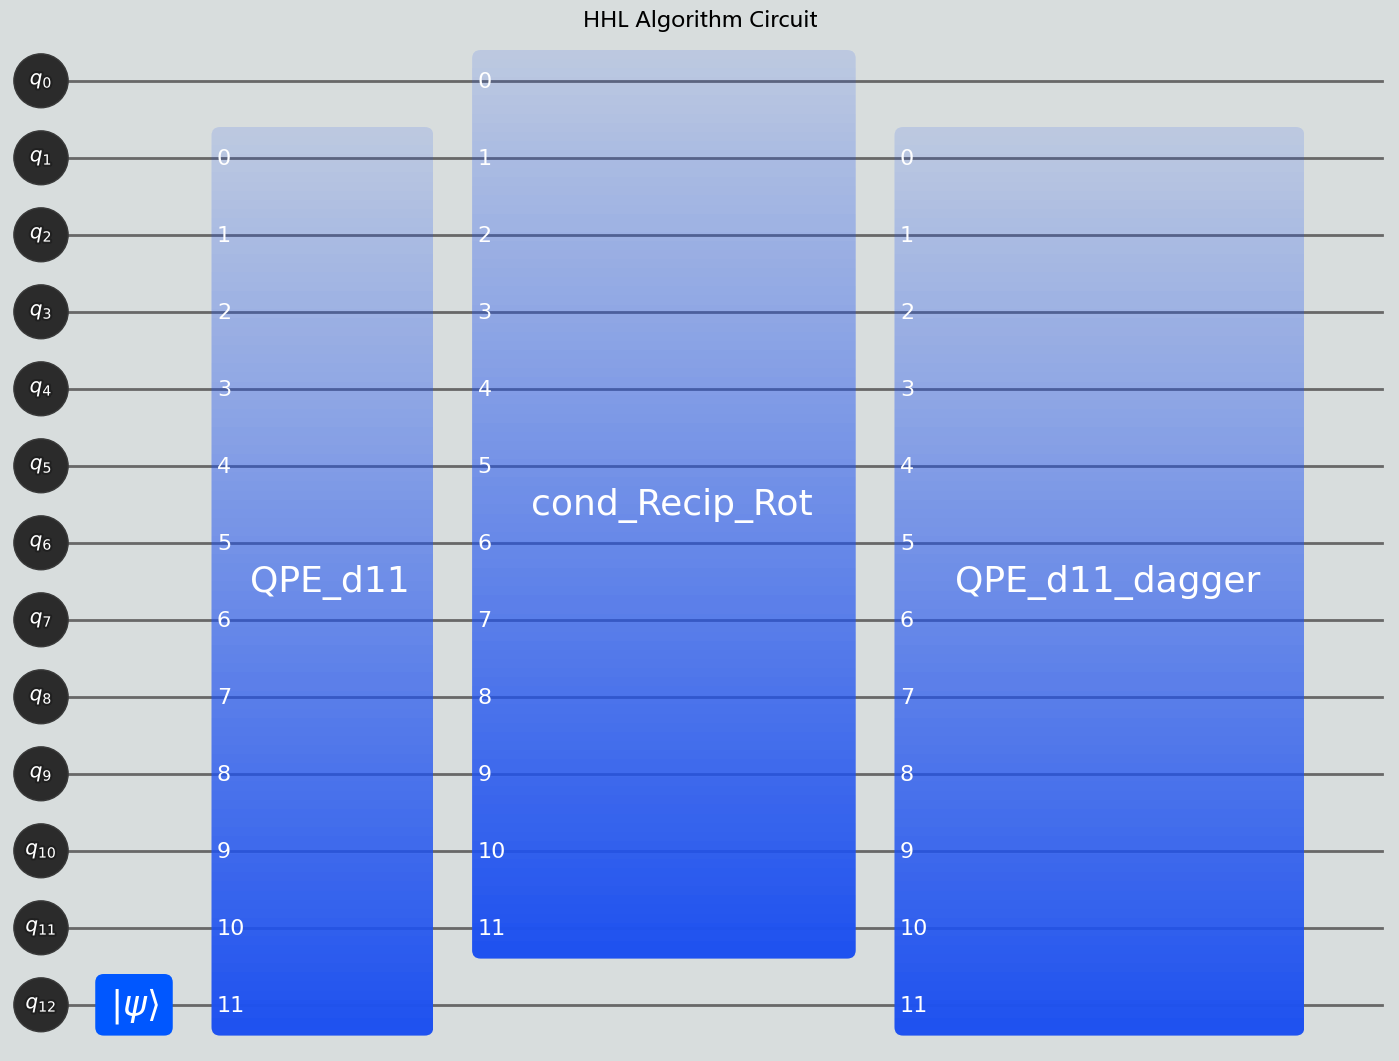

In [8]:
# 运行官方代码
from unitarylab_algorithms import HHLAlgorithm

%matplotlib inline

hhl = HHLAlgorithm(text_mode="plain")
hhl_result = hhl.run(A=A, b=b, d=11, backend="numpy", device="cpu", dtype=np.complex128)

In [9]:
# 官方结果
official_hhl_solution = np.asarray(
    hhl_result["Estimated solution (quantum)"], dtype=complex
)
official_exact_solution = np.asarray(
    hhl_result["Exact solution (classical)"], dtype=complex
)

official_l2_error = hhl_result["L2 error"]
official_postselection = hhl_result["Post-selection probability"]

print("Official HHL solution =", official_hhl_solution)
print("Official exact solution =", official_exact_solution)
print("Official L2 error =", official_l2_error)
print("Official post-selection probability =", official_postselection)

Official HHL solution = [0.70710678-1.40336928e-16j 1.40061536-5.75212906e-16j]
Official exact solution = [0.70710678+0.j 1.41421356+0.j]
Official L2 error = 0.013598200208513989
Official post-selection probability = 0.6028683132979413


In [10]:
# 进行对比
official_hhl_state = official_hhl_solution / np.linalg.norm(official_hhl_solution)
official_hhl_fidelity = abs(np.vdot(x_exact_state, official_hhl_state)) ** 2

print("Official HHL normalized state:", official_hhl_state)
print("Official HHL fidelity:", official_hhl_fidelity)

Official HHL normalized state: [0.45067698-8.94442320e-17j 0.8926871 -3.66613958e-16j]
Official HHL fidelity: 0.9999849771059203


In [11]:
print("\n========== HHL Comparison ==========")
print("Exact state =", x_exact_state)
print("Manual HHL state =", manual_hhl_state)
print("Official HHL state =", official_hhl_state)
print("\nManual fidelity =", manual_fidelity)
print("Official fidelity =", official_hhl_fidelity)
print("\nManual ideal post-selection =", manual_postselection_probability)
print("Official post-selection =", official_postselection)


========== HHL Comparison ==========
Exact state = [0.4472136 +0.j 0.89442719+0.j]
Manual HHL state = [0.4472136 +0.j 0.89442719+0.j]
Official HHL state = [0.45067698-8.94442320e-17j 0.8926871 -3.66613958e-16j]

Manual fidelity = 0.9999999999999998
Official fidelity = 0.9999849771059203

Manual ideal post-selection = 0.6249999999999999
Official post-selection = 0.6028683132979413


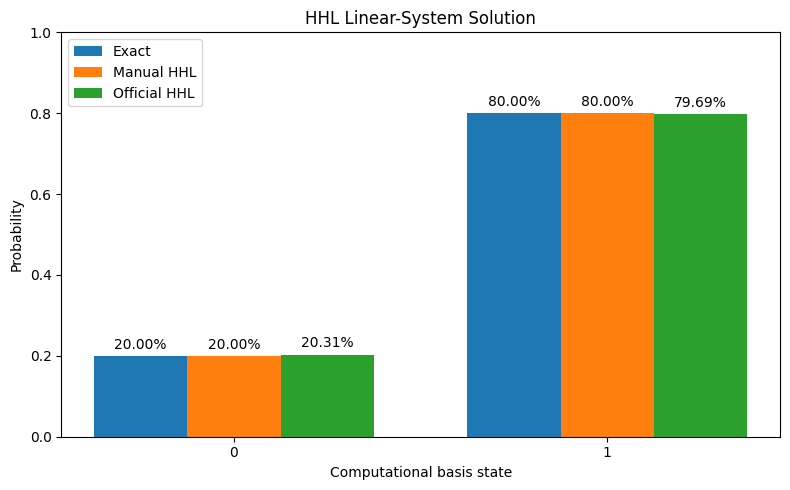

In [12]:
# 绘制解态概率
import matplotlib.pyplot as plt

exact_probabilities = np.abs(x_exact_state) ** 2
manual_probabilities = np.abs(manual_hhl_state) ** 2
official_probabilities = np.abs(official_hhl_state) ** 2

basis_states = ["0", "1"]
positions = np.arange(len(basis_states))

width = 0.25

fig, ax = plt.subplots(figsize=(8, 5))

bars_exact = ax.bar(positions - width, exact_probabilities, width, label="Exact")
bars_manual = ax.bar(positions, manual_probabilities, width, label="Manual HHL")
bars_official = ax.bar(
    positions + width, official_probabilities, width, label="Official HHL"
)

ax.bar_label(
    bars_exact, labels=[f"{p * 100:.2f}%" for p in exact_probabilities], padding=3
)
ax.bar_label(
    bars_manual, labels=[f"{p * 100:.2f}%" for p in manual_probabilities], padding=3
)
ax.bar_label(
    bars_official, labels=[f"{p * 100:.2f}%" for p in official_probabilities], padding=3
)

ax.set_xticks(positions)
ax.set_xticklabels(basis_states)

ax.set_xlabel("Computational basis state")
ax.set_ylabel("Probability")
ax.set_title("HHL Linear-System Solution")
ax.set_ylim(0, 1.0)

ax.legend()
fig.tight_layout()

plt.show()

[QSVT_QLSA]: Starting QSVT Linear Solver
[QSVT_QLSA]: Input parameters: 
        - Matrix in the linear system = [[1. +0.j 0. +0.j]
 [0. +0.j 0.5+0.j]]
        - Source vector = [0.70710678+0.j 0.70710678+0.j]
        - Target precision (epsilon) = 0.001
[QSVT_QLSA]: Calling the QSVT linear solver from unitarylab...
[QSVT_QLSA] Starting QSVT linear solver (target precision=0.001)
[QSVT_QLSA] Stage 1/4: Classical preprocessing (computing Chebyshev approximation coefficients)...
  - Matrix condition number (kappa): 2.0
  - Block-Encoding factor (alpha): 1.0
  - Highest truncated polynomial degree: 41
[QSVT_QLSA] Stage 1/4 complete ✓
[QSVT_QLSA] Stage 2/4: Building QSVT quantum circuit...
  - Loaded normalized source state |b>
  - Calling QSP engine to generate polynomial Block-Encoding circuit...
[QSVT_QLSA] Stage 2/4 complete ✓
[QSVT_QLSA] Stage 3/4: Running quantum simulation...
  - Core simulation time: 0.0035 s
[QSVT_QLSA] Stage 3/4 complete ✓
[QSVT_QLSA] Stage 4/4: Running classical

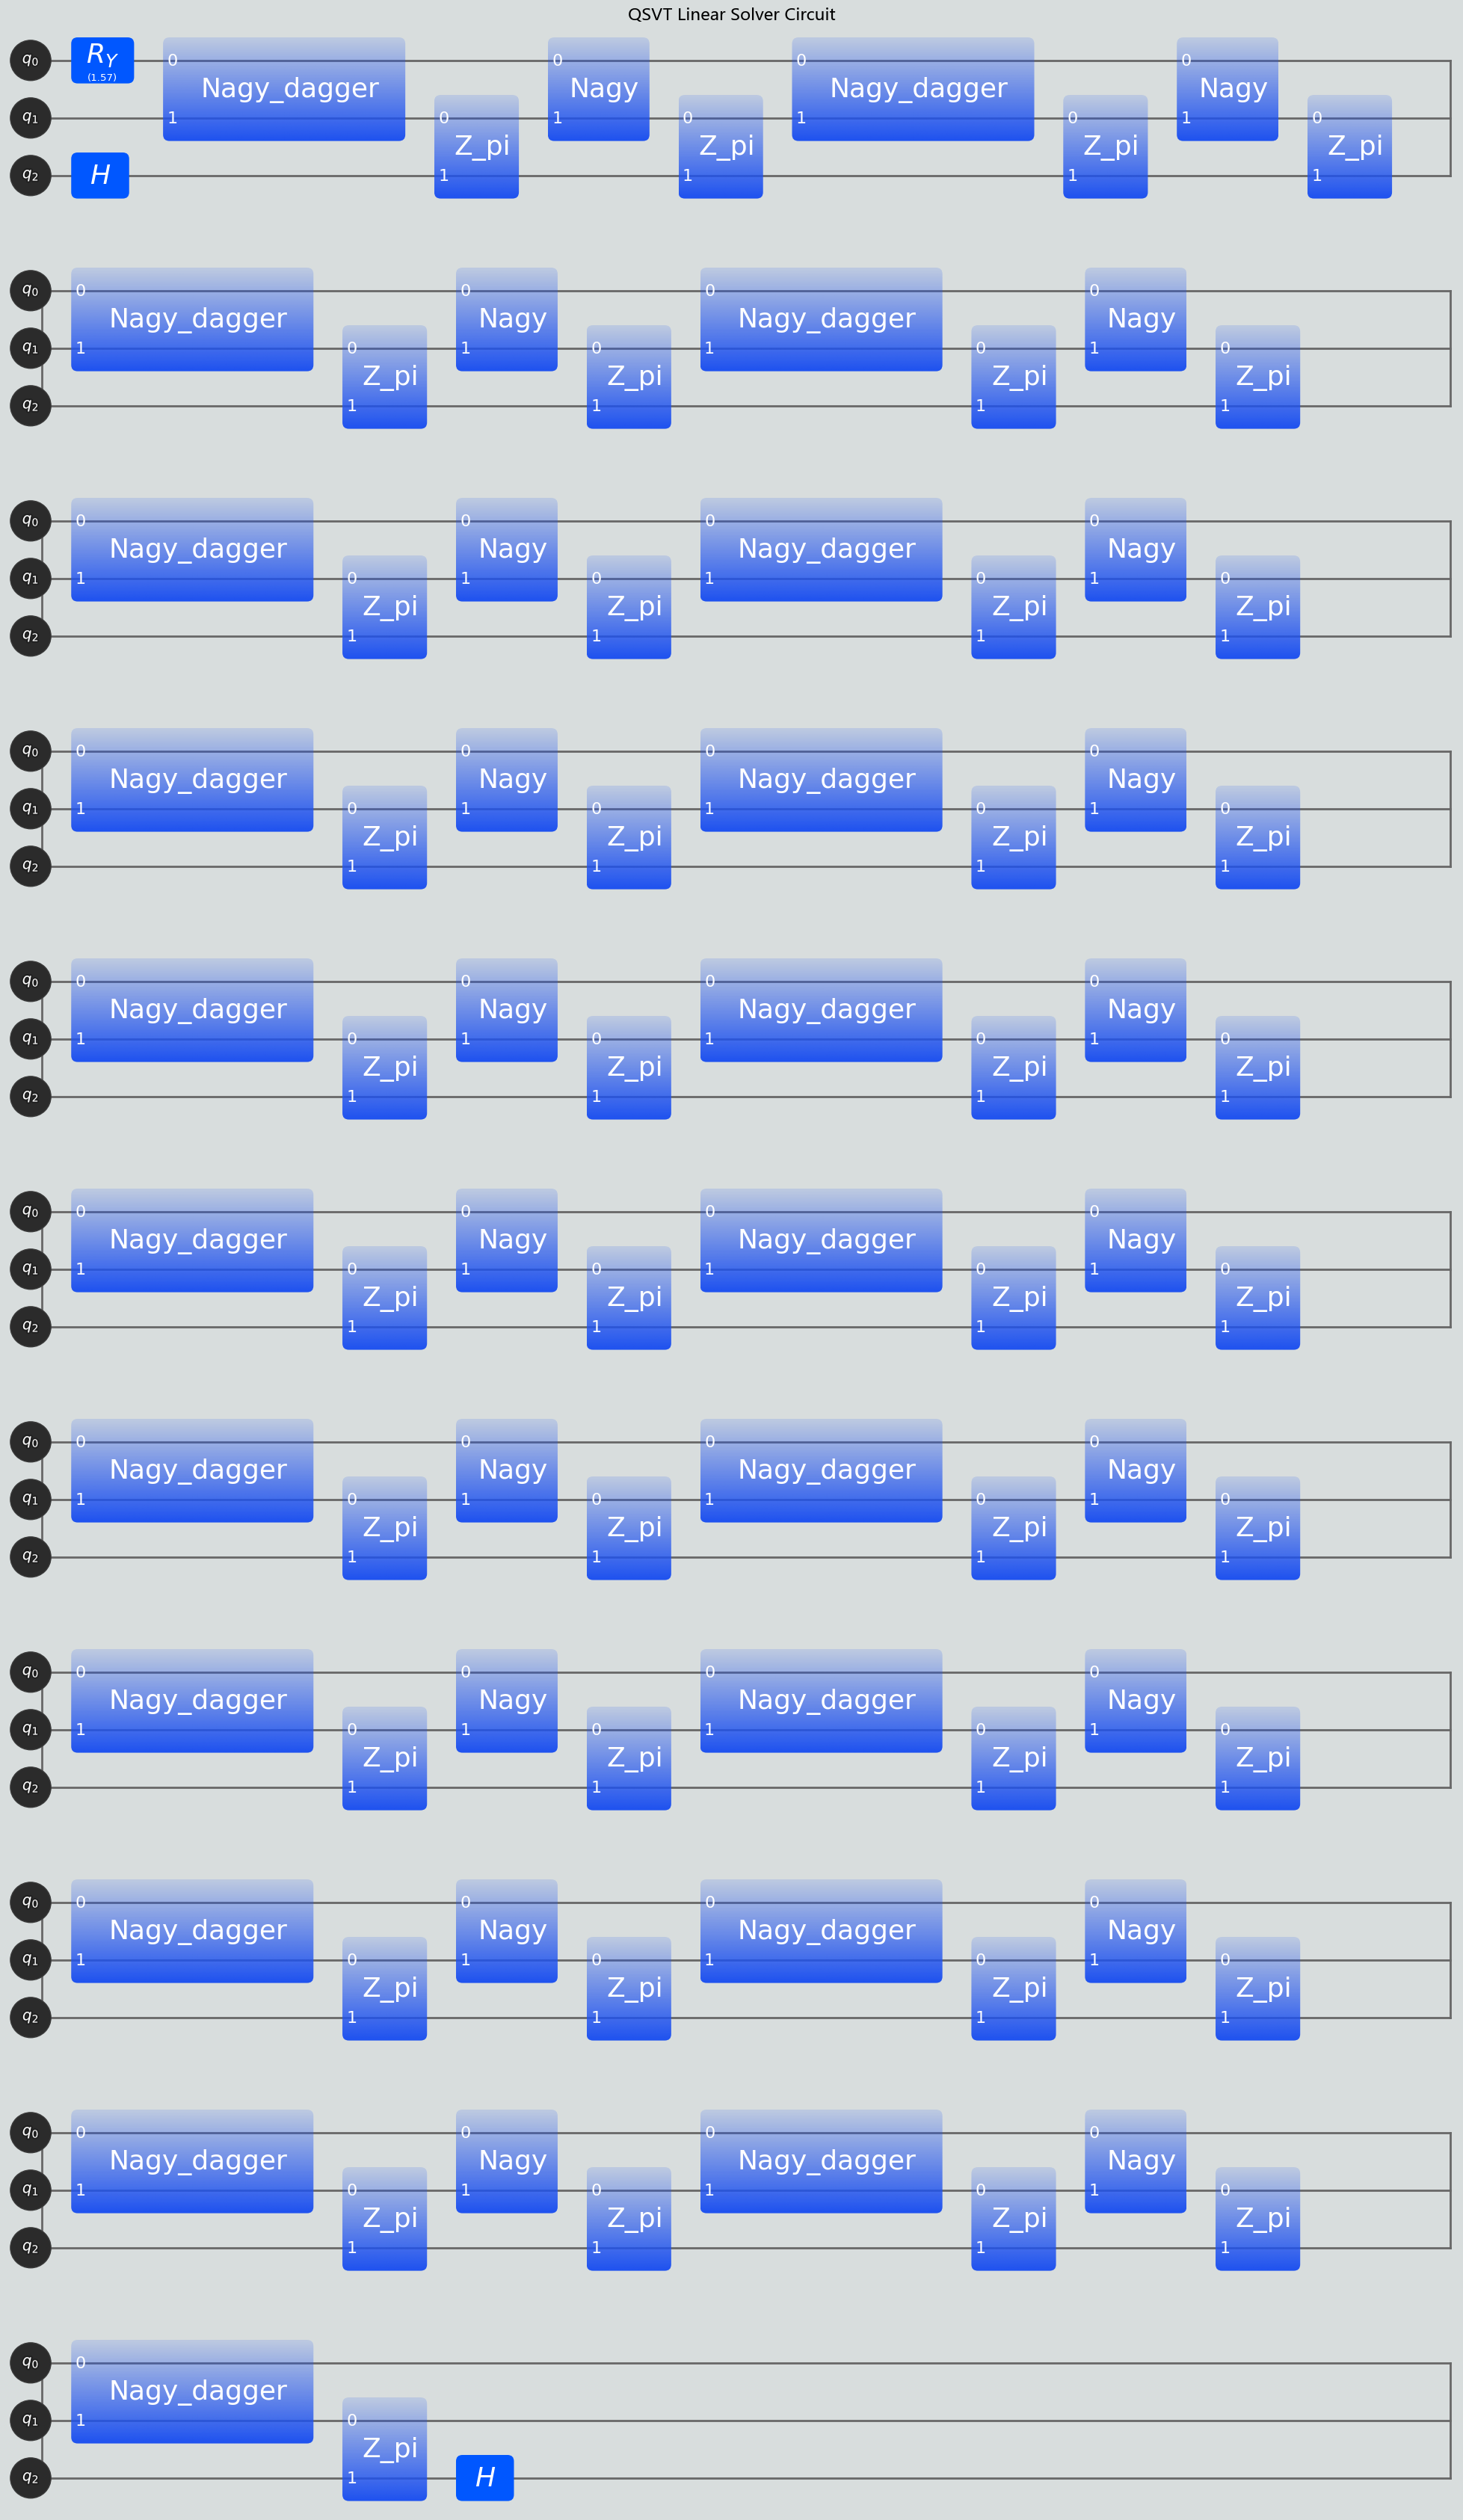

In [13]:
# 和 QSVT 对比
from unitarylab_algorithms import QSVTLinearSolverAlgorithm

qsvt_solver = QSVTLinearSolverAlgorithm(text_mode="plain")
qsvt_result = qsvt_solver.run(
    A=A,
    b=b,
    epsilon=1e-3,
    backend="numpy",
    device="cpu",
    dtype=np.complex128,
)

In [14]:
qsvt_soltion = np.asarray(qsvt_result["Solution vector"], dtype=complex)
qsvt_state = qsvt_soltion / np.linalg.norm(qsvt_soltion)

qsvt_fidelity = abs(np.vdot(x_exact_state, qsvt_state)) ** 2

print("\n========== HHL vs QSVT ==========")
print("Exact state =", x_exact_state)
print("HHL state =", official_hhl_state)
print("QSVT state =", qsvt_state)
print("\nHHL fidelity =", official_hhl_fidelity)
print("QSVT fidelity =", qsvt_fidelity)


========== HHL vs QSVT ==========
Exact state = [0.4472136 +0.j 0.89442719+0.j]
HHL state = [0.45067698-8.94442320e-17j 0.8926871 -3.66613958e-16j]
QSVT state = [0.44726152+0.j 0.89440323+0.j]

HHL fidelity = 0.9999849771059203
QSVT fidelity = 0.9999999971286744


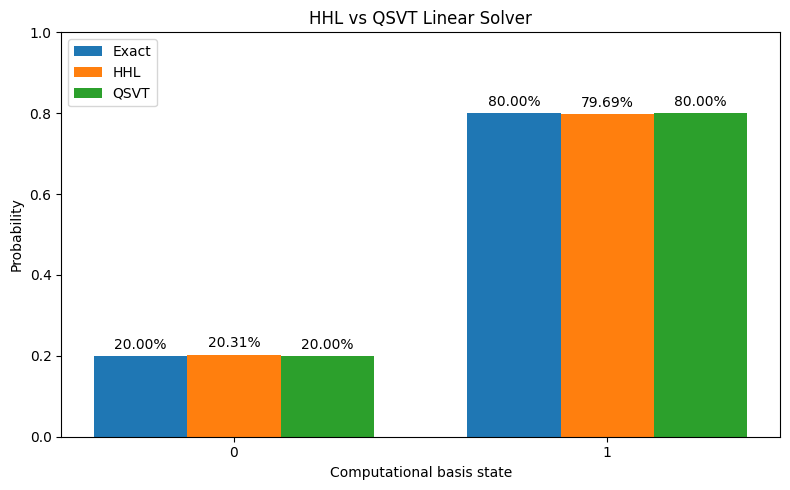

In [15]:
# 绘制图表
hhl_probabilities = np.abs(official_hhl_state) ** 2
qsvt_probabilities = np.abs(qsvt_state) ** 2

positions = np.arange(2)

width = 0.25

fig, ax = plt.subplots(figsize=(8, 5))

bars_exact = ax.bar(positions - width, exact_probabilities, width, label="Exact")
bars_hhl = ax.bar(positions, hhl_probabilities, width, label="HHL")
bars_qsvt = ax.bar(positions + width, qsvt_probabilities, width, label="QSVT")

ax.bar_label(
    bars_exact, labels=[f"{p * 100:.2f}%" for p in exact_probabilities], padding=3
)
ax.bar_label(bars_hhl, labels=[f"{p * 100:.2f}%" for p in hhl_probabilities], padding=3)
ax.bar_label(
    bars_qsvt, labels=[f"{p * 100:.2f}%" for p in qsvt_probabilities], padding=3
)

ax.set_xticks(positions)
ax.set_xticklabels(["0", "1"])

ax.set_xlabel("Computational basis state")
ax.set_ylabel("Probability")
ax.set_title("HHL vs QSVT Linear Solver")
ax.set_ylim(0, 1.0)

ax.legend()
fig.tight_layout()

plt.show()

[HHL]: Starting HHL Algorithm
[HHL]: Input parameters: 
        - Matrix = [[1. +0.j 0. +0.j]
 [0. +0.j 0.5+0.j]]
        - Right-hand side = [0.70710678+0.j 0.70710678+0.j]
        - Phase bits = 7
[HHL]: Stage 1: Matrix preprocessing and adaptive parameter analysis
[HHL]:   System dimension (N): 2 (1 System Qubits)
[HHL]:   Auto evolution time (t): 0.992188
[HHL]:   Phase grid starting point (k_start): 53
[HHL]:   Phase decoding mode: unsigned
[HHL]: Stage 2: Building HHL quantum circuit
[HHL]:   State preparation module mounted: Initialize |b>
[HHL]:   QPE module mounted: Extract eigenphases
[HHL]:   Controlled reciprocal rotation module mounted: Nonlinear mapping 1/lambda
[HHL]:   Inverse QPE (iQPE) module mounted: System disentanglement
[HHL]: Stage 3: Executing quantum simulation
[HHL]:   Low-level simulation time: 0.0190 seconds
[HHL]: Stage 4: Classical post-processing (post-selection to extract solution)
0.4278620221668281
[HHL]:   Post-selection success probability P(anc=1, p

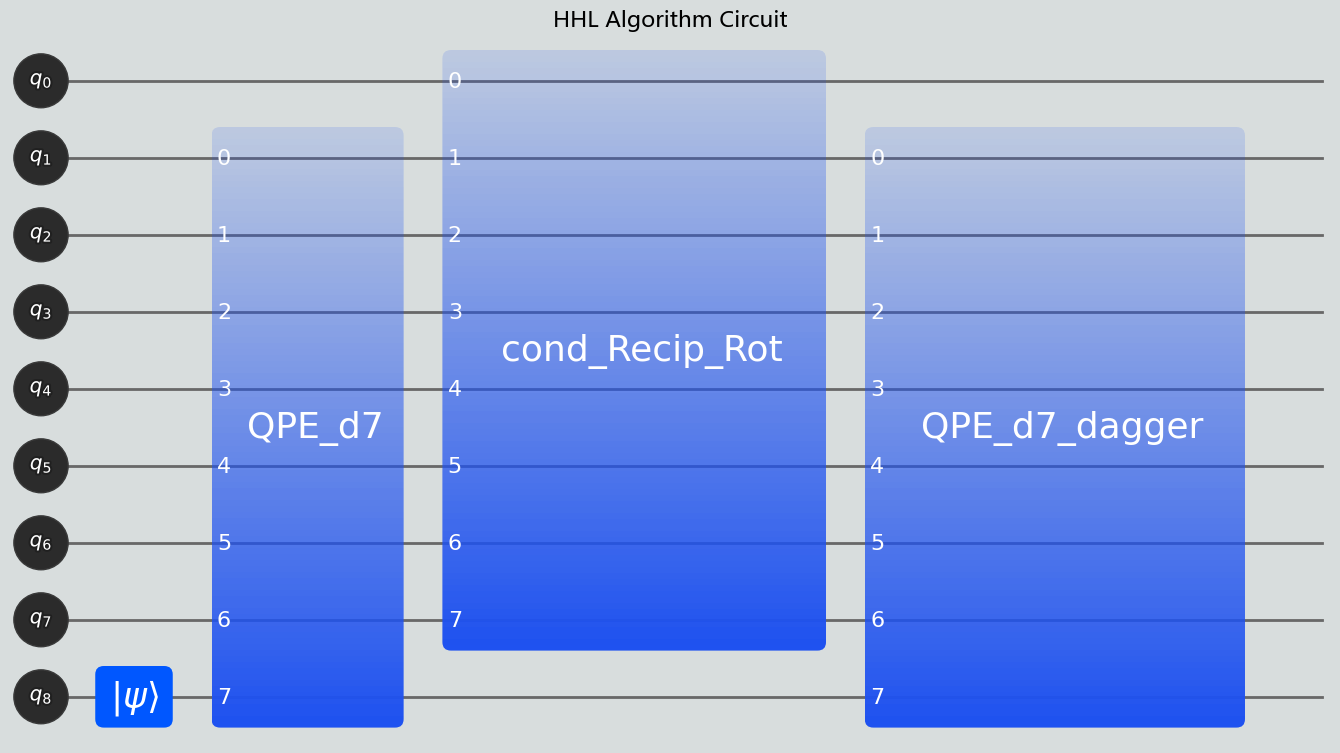

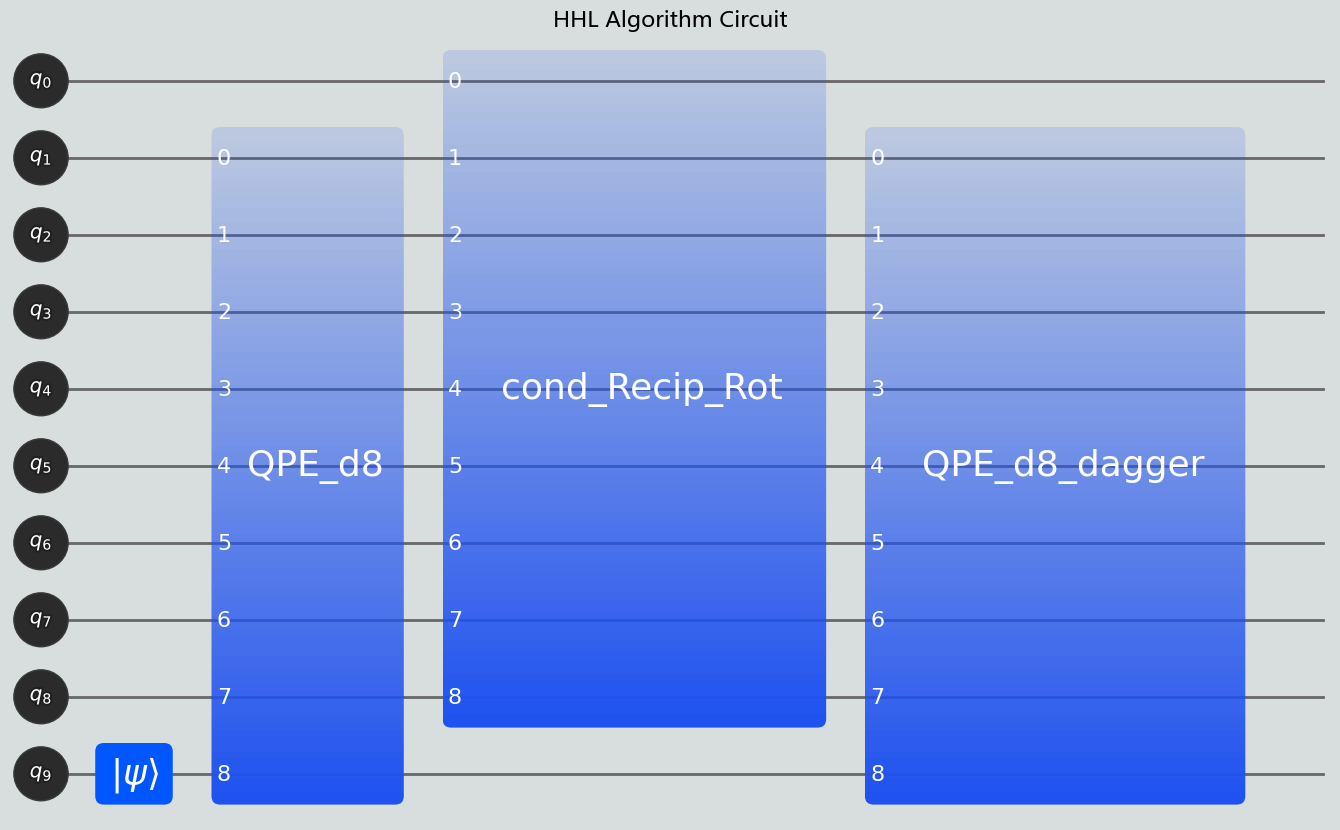

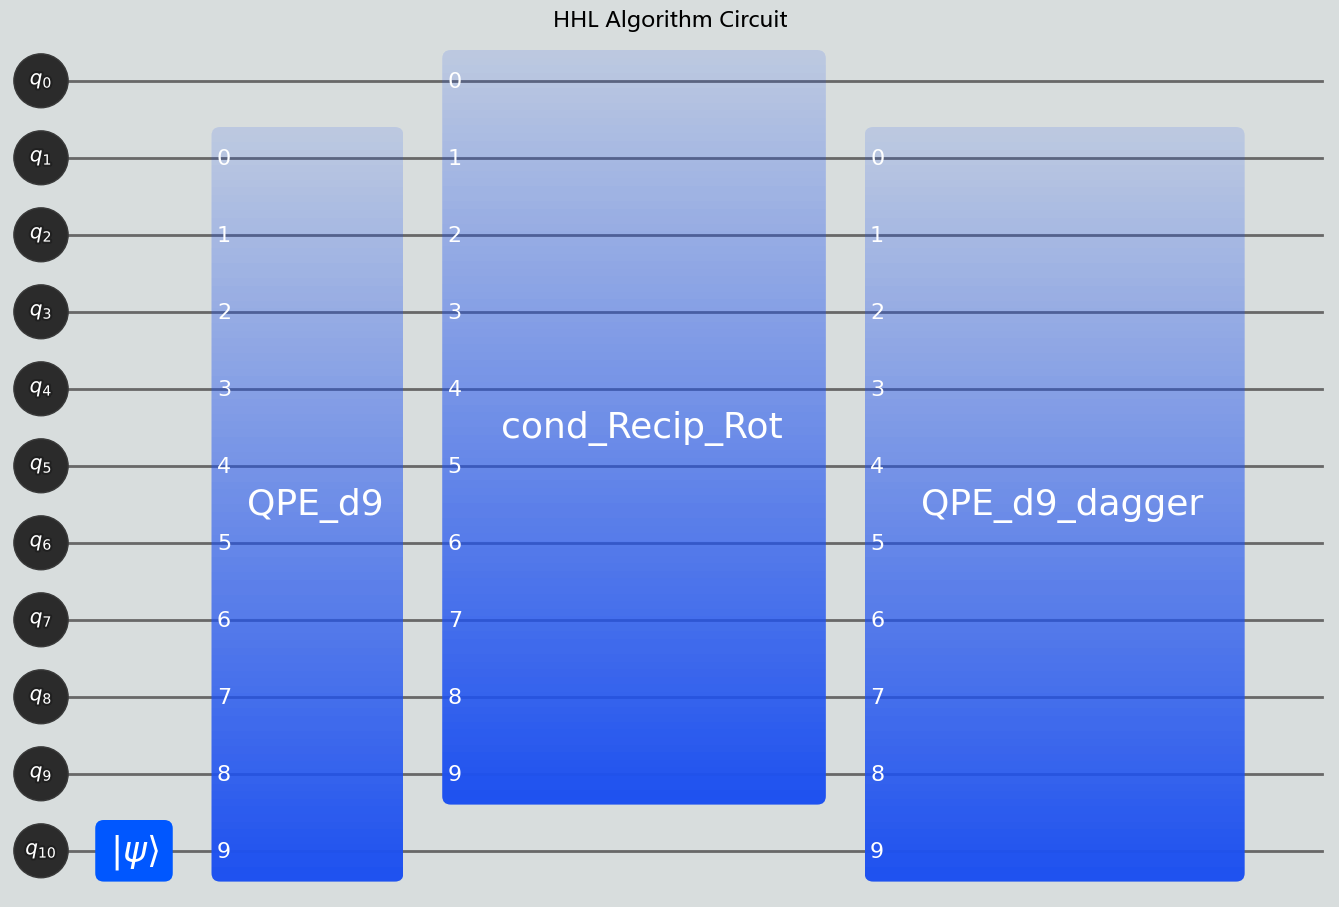

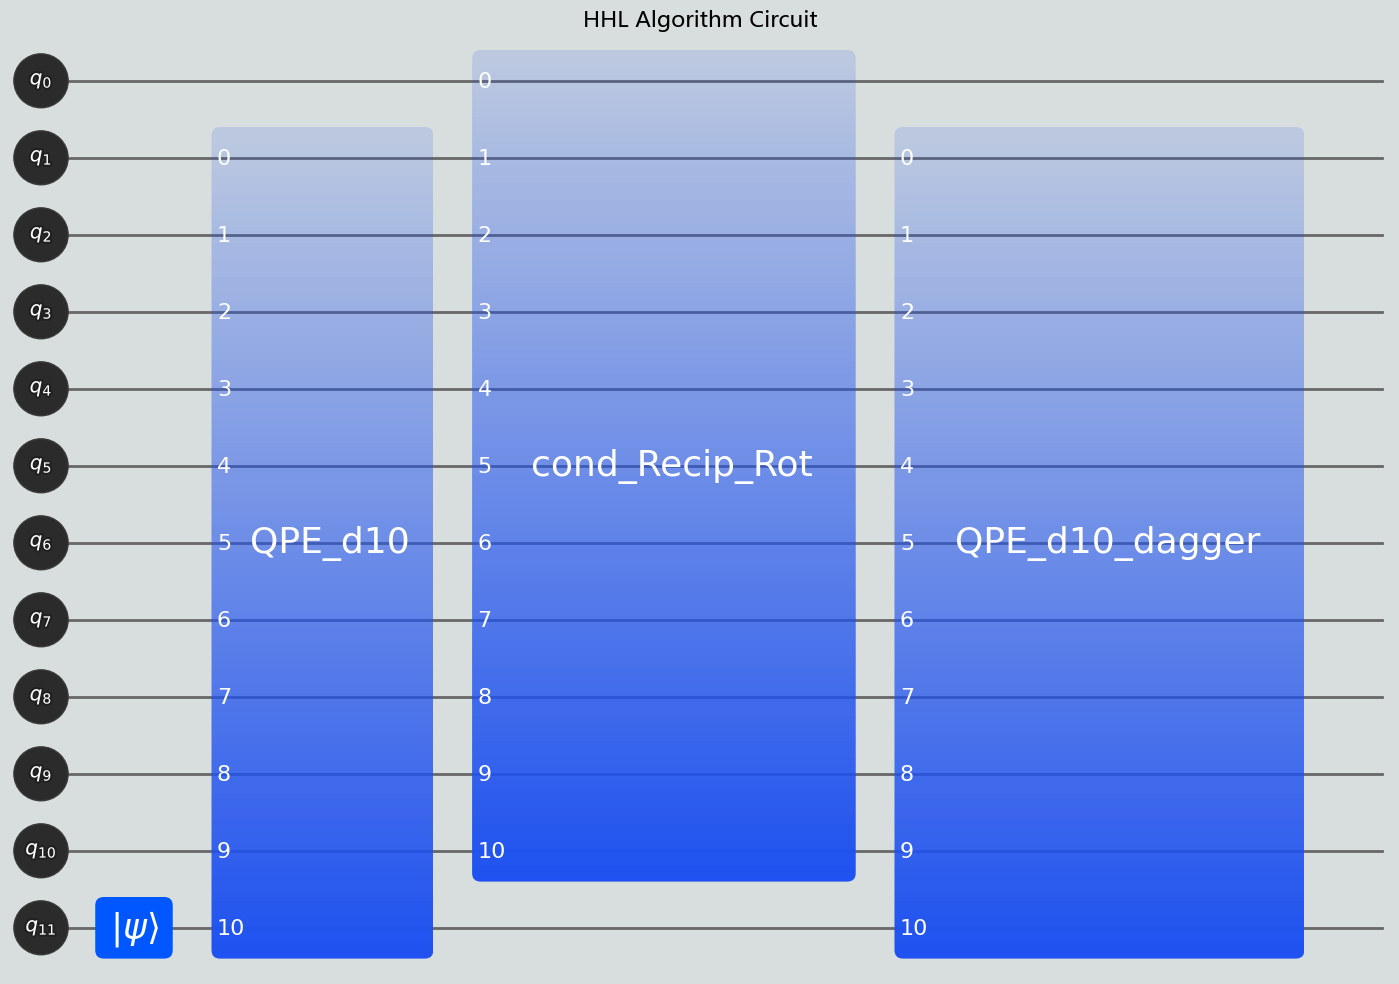

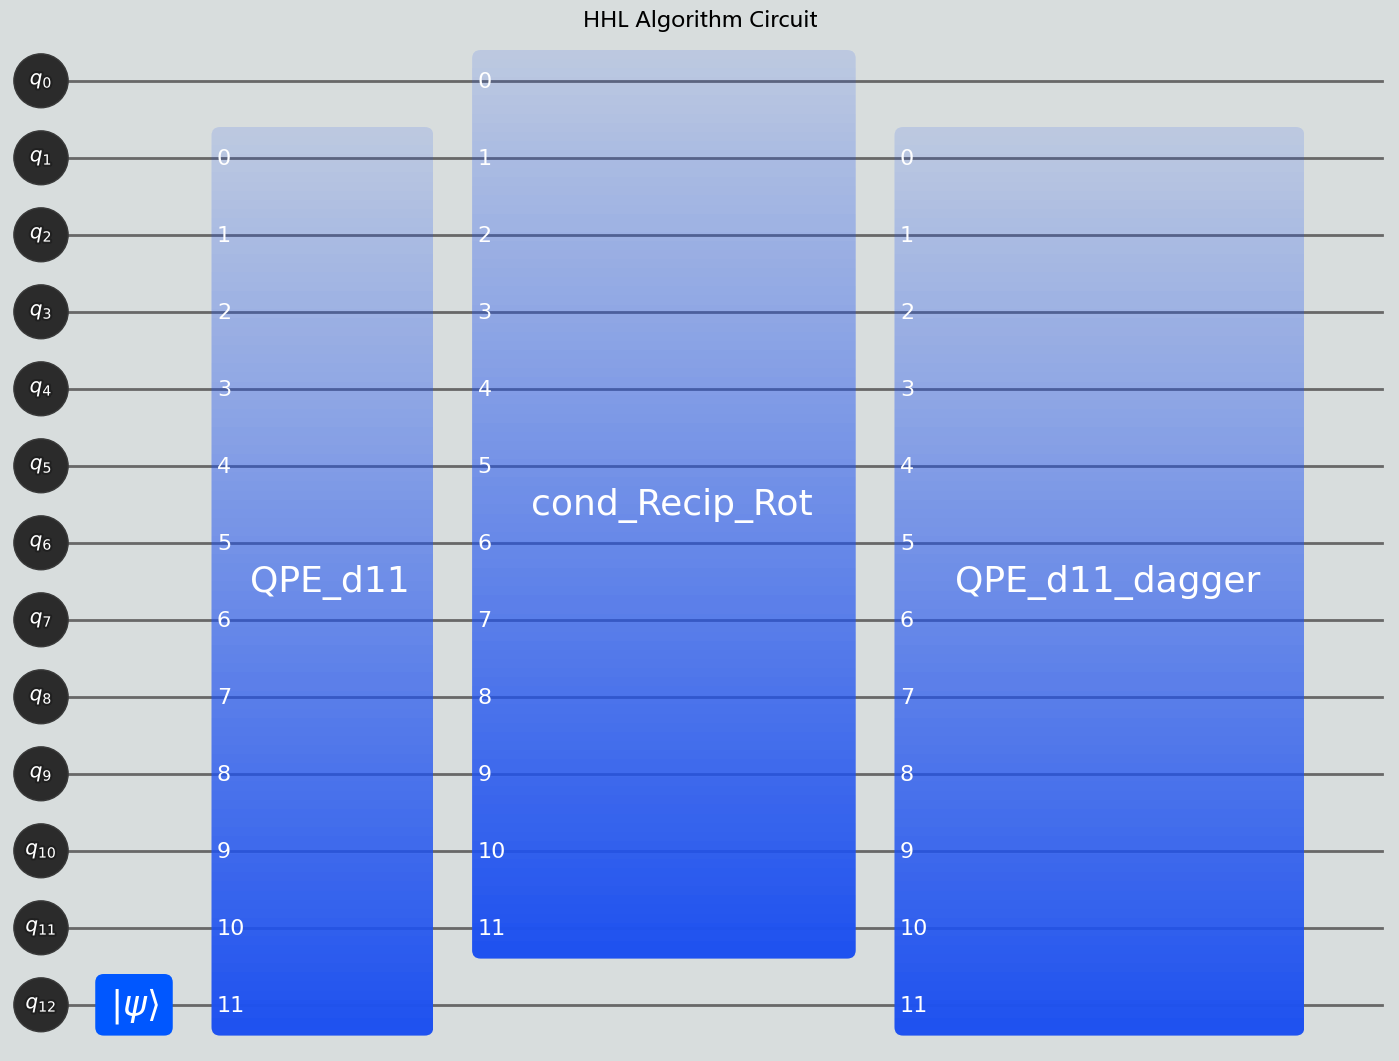

In [16]:
# 增加 d, 进行 HHL 精度实验
phase_bits = [7, 8, 9, 10, 11]

hhl_errors = []
hhl_fidelities = []

for d in phase_bits:
    try:
        result_d = hhl.run(
            A=A, b=b, d=d, backend="numpy", device="cpu", dtype=np.complex128
        )

        solution_d = np.asarray(result_d["Estimated solution (quantum)"], dtype=complex)

        state_d = solution_d / np.linalg.norm(solution_d)

        fidelity_d = abs(np.vdot(x_exact_state, state_d)) ** 2

        error_d = result_d["L2 error"]

    except ValueError:
        fidelity_d = np.nan
        error_d = np.nan

    hhl_fidelities.append(fidelity_d)
    hhl_errors.append(error_d)


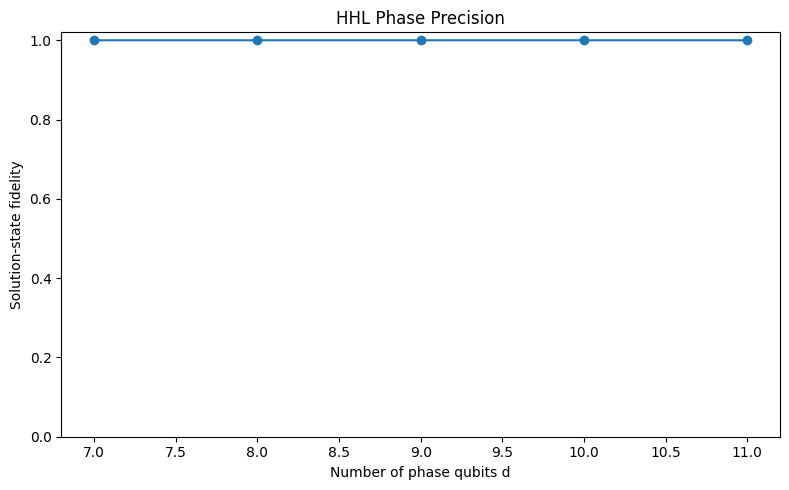

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(phase_bits, hhl_fidelities, marker="o")

ax.set_xlabel("Number of phase qubits d")
ax.set_ylabel("Solution-state fidelity")
ax.set_title("HHL Phase Precision")
ax.set_ylim(0, 1.02)

fig.tight_layout()

plt.show()